# Exploración de datos: localización subcelular de proteínas

Este notebook trabaja sobre los archivos que ya vienen generados por `01_construir_dataset.py`:

- `features_composicion_fisicoquimicos.csv` — accession, sequence, length, bag of aminoácidos (20), features fisicoquímicos (13), localization
- `features_dipeptidos_fisicoquimicos.csv` — accession, sequence, length, dipéptidos (400), features fisicoquímicos (13), localization
- `features_composicion_senales_fisicoquimicos.csv` — lo mismo que la composición, más 11 señales derivadas de la secuencia: péptido señal, NLS (mono y bipartita) y dominios transmembrana (alfa-hélice y una propensión beta)

El objetivo es explorar visualmente estos datos **antes** de pasar a Orange, para tener una
intuición de qué representa cada clase y qué features podrían ser más útiles.

## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

comp = pd.read_csv("features_composicion_fisicoquimicos.csv")
dip = pd.read_csv("features_dipeptidos_fisicoquimicos.csv")
sen = pd.read_csv("features_composicion_senales_fisicoquimicos.csv")

AMINOACIDOS = list("ACDEFGHIKLMNPQRSTVWY")
FISICOQUIMICOS = ["peso_molecular", "punto_isoelectrico", "hidrofobicidad_promedio",
                   "aromaticidad", "indice_inestabilidad", "carga_neta_pH7",
                   "indice_alifatico", "fraccion_cargados", "coef_extincion_molar"]
SENALES = ["senal_peptido", "senal_hidrofobicidad_max", "nls_monopartita",
           "nls_bipartita", "nls_densidad_basica_10", "nls_carga_neta_nterm20",
           "tmd_alfa_helices", "tmd_alfa_hidrofobicidad_max",
           "tmd_beta_momento_hidrofobico"]

sns.set_style("whitegrid")
comp.head()

## 1. Balance de clases

**Prompt sugerido para la IA (referencia):**

> "Con este DataFrame de pandas `comp`, que tiene una columna categórica `localization`
con 3 valores posibles, generá un gráfico de barras (countplot de seaborn) que muestre
cuántas proteínas hay de cada clase. Agregale título y ejes."

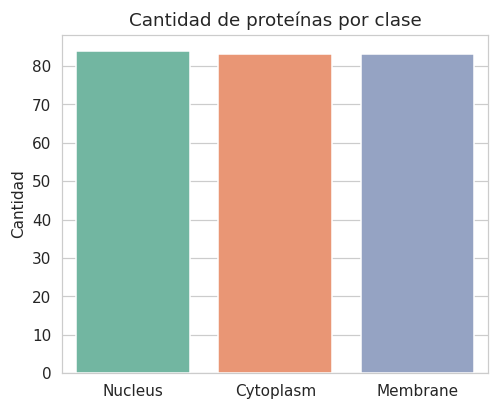

In [ ]:
plt.figure(figsize=(5, 4))
order = comp["localization"].value_counts().index
sns.countplot(data=comp, x="localization", order=order, palette="Set2")
plt.title("Cantidad de proteínas por clase")
plt.xlabel("")
plt.ylabel("Cantidad")
plt.show()

**Interpretación:** ¿Las clases están razonablemente balanceadas?

*(guía de discusión para el docente — no hay una única respuesta correcta, pero se espera que Membrana sea la clase que más se distinga)*

## 2. Distribución de longitud por clase

**Prompt sugerido para la IA (referencia):**

> "Con el mismo DataFrame `comp`, que además tiene una columna numérica `length`,
generá un boxplot que compare la distribución de `length` entre las 3 clases de `localization`."

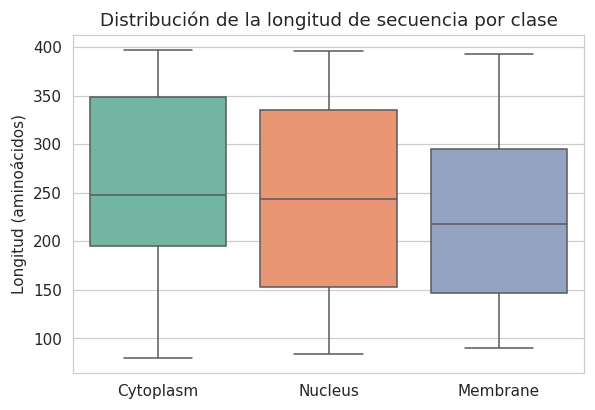

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=comp, x="localization", y="length", palette="Set2")
plt.title("Distribución de la longitud de secuencia por clase")
plt.xlabel("")
plt.ylabel("Longitud (aminoácidos)")
plt.show()

**Interpretación:** ¿Hay diferencias notorias de longitud entre clases? ¿Podría esto sesgar al modelo?

*(guía de discusión para el docente — no hay una única respuesta correcta, pero se espera que Membrana sea la clase que más se distinga)*

## 3. Composición aminoacídica promedio por clase

**Prompt sugerido para la IA (referencia):**

> "Tengo un DataFrame `comp` con 20 columnas (una por aminoácido, con las letras
A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y) que representan proporciones, más una columna
`localization`. Quiero un heatmap donde las filas sean las 3 clases y las columnas los 20
aminoácidos, mostrando el promedio de cada aminoácido por clase. Usá seaborn.heatmap."

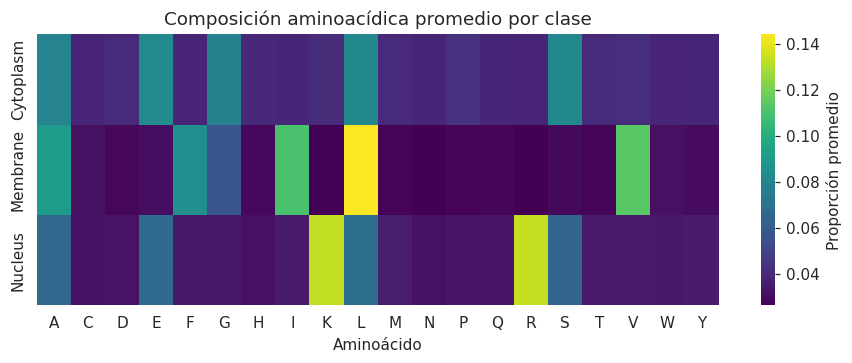

In [ ]:
AMINOACIDOS = list("ACDEFGHIKLMNPQRSTVWY")
promedio_por_clase = comp.groupby("localization")[AMINOACIDOS].mean()

plt.figure(figsize=(10, 3.2))
sns.heatmap(promedio_por_clase, cmap="viridis", cbar_kws={"label": "Proporción promedio"})
plt.title("Composición aminoacídica promedio por clase")
plt.xlabel("Aminoácido")
plt.ylabel("")
plt.show()

**Interpretación:** ¿Qué aminoácidos se ven más distintos entre clases? ¿Coincide con lo que esperarían biológicamente (por ejemplo, aminoácidos hidrofóbicos en membrana)?

*(guía de discusión para el docente — no hay una única respuesta correcta, pero se espera que Membrana sea la clase que más se distinga)*

## 4. Features fisicoquímicos por clase

**Prompt sugerido para la IA (referencia):**

> "Con el DataFrame `comp`, que tiene las columnas ['peso_molecular',
'punto_isoelectrico', 'hidrofobicidad_promedio', 'aromaticidad', 'indice_inestabilidad',
'carga_neta_pH7'] y una columna `localization`, generá una grilla de 2x3 subplots con un
boxplot de cada feature comparando las 3 clases."

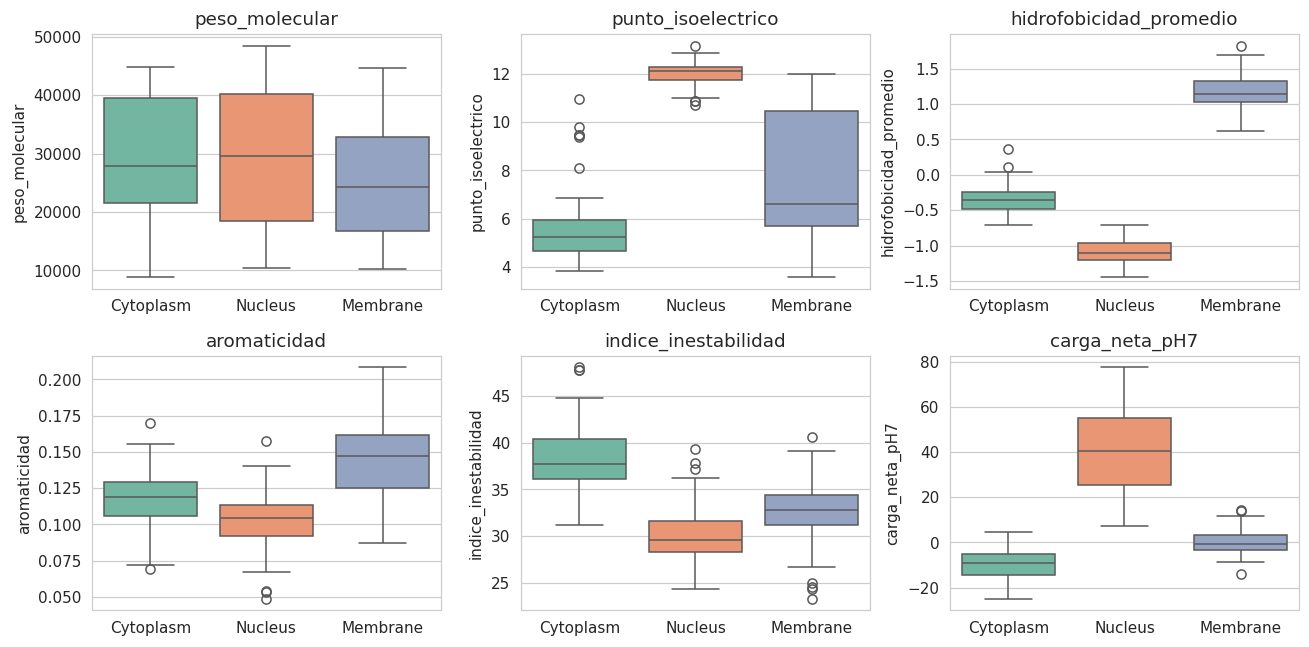

In [ ]:
FISICOQUIMICOS = ["peso_molecular", "punto_isoelectrico", "hidrofobicidad_promedio",
                   "aromaticidad", "indice_inestabilidad", "carga_neta_pH7"]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, feat in zip(axes.flat, FISICOQUIMICOS):
    sns.boxplot(data=comp, x="localization", y=feat, ax=ax, palette="Set2")
    ax.set_xlabel("")
    ax.set_title(feat)
plt.tight_layout()
plt.show()

**Interpretación:** ¿Cuál de estos features parece separar mejor alguna clase? Anótenlo, lo vamos a poder confirmar después con el widget Rank en Orange.

*(guía de discusión para el docente — no hay una única respuesta correcta, pero se espera que Membrana sea la clase que más se distinga)*

## 5. Dipéptidos más variables entre clases

**Prompt sugerido para la IA (referencia):**

> "Tengo un DataFrame `dip` con 400 columnas de dipéptidos (nombradas con 2 letras,
por ejemplo 'AA', 'AC', etc.) más una columna `localization`. Quiero: (1) calcular el promedio
de cada dipéptido agrupado por clase, (2) quedarme con los 20 dipéptidos cuya varianza entre
clases sea mayor, y (3) graficar un heatmap de esos 20 dipéptidos (filas=clases, columnas=dipéptidos)."

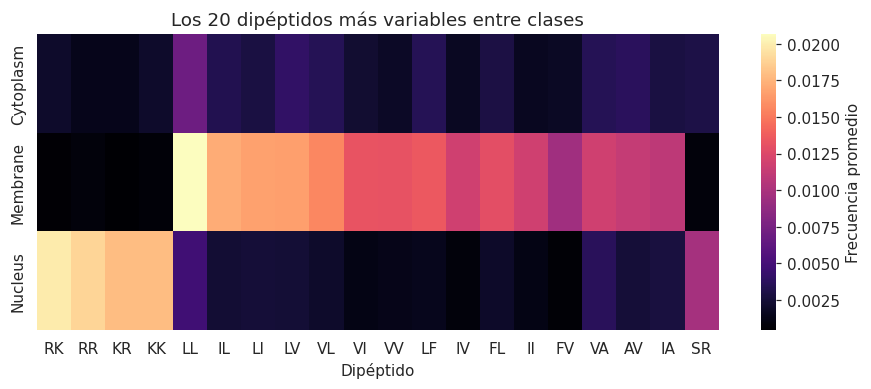

In [ ]:
dip_cols = [c for c in dip.columns if len(c) == 2 and c.isalpha()]
promedio_dip = dip.groupby("localization")[dip_cols].mean()
top20 = promedio_dip.var(axis=0).sort_values(ascending=False).head(20).index

plt.figure(figsize=(10, 3.5))
sns.heatmap(promedio_dip[top20], cmap="magma", cbar_kws={"label": "Frecuencia promedio"})
plt.title("Los 20 dipéptidos más variables entre clases")
plt.xlabel("Dipéptido")
plt.ylabel("")
plt.show()

**Interpretación:** ¿Reconocen algún patrón (por ejemplo, dipéptidos con L o V destacándose en Membrana)?

*(guía de discusión para el docente — no hay una única respuesta correcta, pero se espera que Membrana sea la clase que más se distinga)*

## 6. Señales posicionales por clase (NLS, péptido señal, TMD)


**Prompt sugerido para la IA:**

> "Tengo un DataFrame `sen` con las columnas `senal_peptido` (0/1), `senal_hidrofobicidad_max`,
`nls_monopartita`, `nls_bipartita`, `nls_densidad_basica_10`, `nls_carga_neta_nterm20`,
`tmd_alfa_helices`, `tmd_alfa_hidrofobicidad_max` y `tmd_beta_momento_hidrofobico`, más una
columna `localization`. Generá una grilla de subplots con un boxplot de cada feature comparando
las 3 clases, y un gráfico de barras aparte con el promedio de `senal_peptido` por clase."


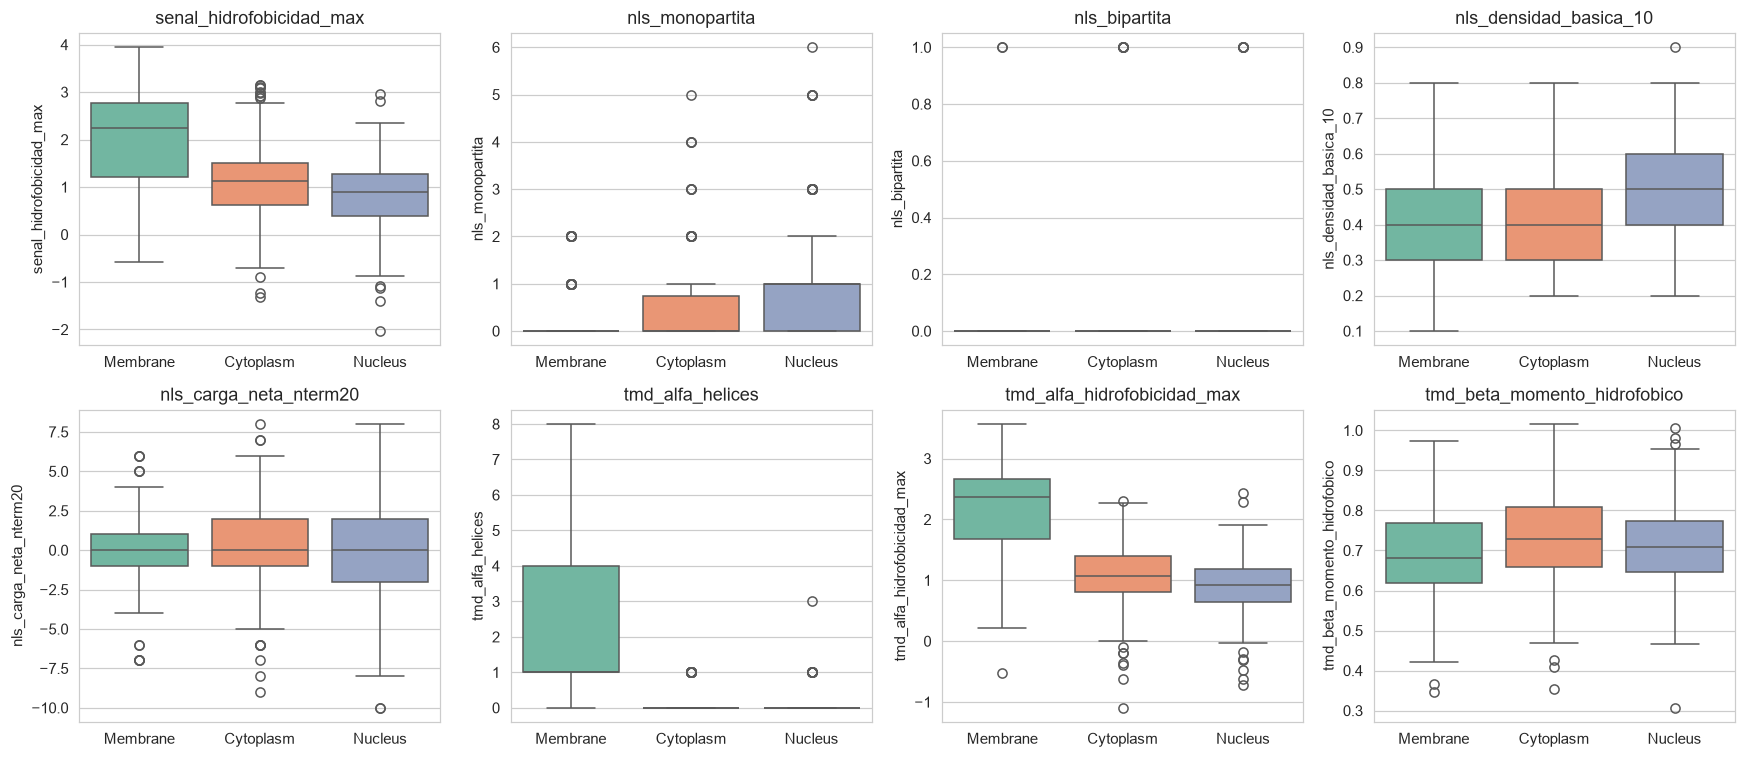

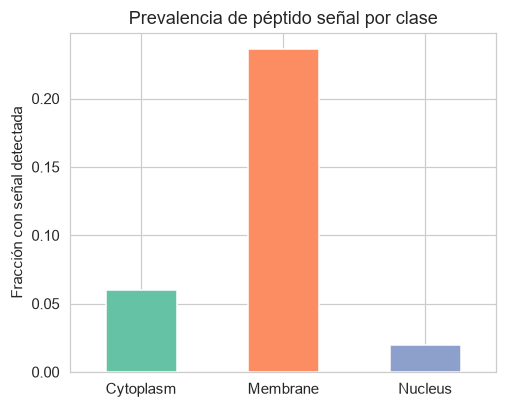

In [1]:
continuas = [f for f in SENALES if f != "senal_peptido"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, feat in zip(axes.flat, continuas):
    sns.boxplot(data=sen, x="localization", y=feat, ax=ax, palette="Set2")
    ax.set_xlabel("")
    ax.set_title(feat)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sen.groupby("localization")["senal_peptido"].mean().plot.bar(
    color=["#66c2a5", "#fc8d62", "#8da0cb"])
plt.title("Prevalencia de péptido señal por clase")
plt.ylabel("Fracción con señal detectada")
plt.xlabel("")
plt.xticks(rotation=0)
plt.show()


**Interpretación:** `tmd_alfa_helices` y `senal_hidrofobicidad_max` separan Membrana del resto, y
los NLS son más frecuentes en Núcleo. El descriptor beta (`tmd_beta_momento_hidrofobico`) NO separa
bien: en proteínas humanas los beta-barriles de membrana son raros, así que una heurística de
secuencia no alcanza (haría falta TMbed/DeepTMHMM). Esta representación (Bloque 5) suele dar el
mejor desempeño: agregar biología posicional explícita rompe el techo que no rompieron los
dipéptidos.

*(guía de discusión para el docente)*


## 7. Referencia: overfitting y Random Forest regularizado


El Random Forest sin límites **memoriza** el train (F1 train = 1.000) y la brecha contra
el test es grande. Al limitar profundidad, mínimo de muestras por hoja y número de hojas
(`min_samples_leaf=10`, `max_depth=8`, `min_samples_split=10`, `max_leaf_nodes=16`) baja el
F1 de train y se achica la brecha — pero también cae algo el F1 de test: es el *tradeoff*
sesgo-varianza. Regularizar da un modelo más **honesto**, no necesariamente mejor.

*(Bloque 5 de la clase. Los números completos, con test reservado y las tres
representaciones, están en `data/03_experimentos.py`.)*

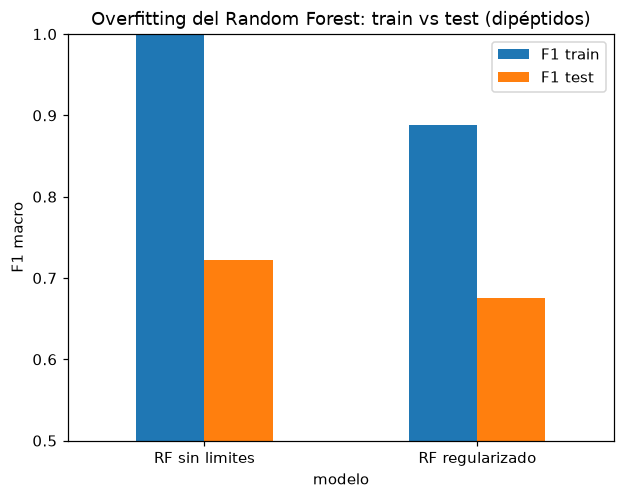

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

DIP = [c for c in dip.columns if len(c) == 2 and c.isalpha()]
X = dip[DIP + FISICOQUIMICOS].to_numpy(float)
y = dip["localization"].to_numpy()
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

def train_test_gap(rf):
    rf.fit(Xtr, ytr)
    tr = f1_score(ytr, rf.predict(Xtr), average="macro")
    te = f1_score(yte, rf.predict(Xte), average="macro")
    return tr, te, tr - te

base = train_test_gap(RandomForestClassifier(300, random_state=0))
reg = train_test_gap(RandomForestClassifier(
    300, random_state=0, min_samples_leaf=10, max_depth=8,
    min_samples_split=10, max_leaf_nodes=16))

tabla = pd.DataFrame({
    "modelo": ["RF sin limites", "RF regularizado"],
    "F1 train": [base[0], reg[0]], "F1 test": [base[1], reg[1]],
    "brecha": [base[2], reg[2]]}).round(3)
print(tabla.to_string(index=False))

tabla.set_index("modelo")[["F1 train", "F1 test"]].plot.bar(rot=0)
plt.title("Overfitting del Random Forest: train vs test (dipéptidos)")
plt.ylabel("F1 macro")
plt.ylim(0.5, 1.0)
plt.show()


**Interpretación:** ¿cuánto baja la brecha? ¿y cuánto baja el F1 del test? Moraleja:
regularizar no inventa un modelo mejor, sino uno **más honesto**. En Orange, el widget Random Forest
sólo permite limitar profundidad y el mínimo para partir (no expone `min_samples_leaf` ni
`max_leaf_nodes`), así que la regularización es más débil.


## Síntesis

*(mismas consignas que la guía de alumnos; las respuestas esperables se contrastan con los Bloques 3-5 de Orange)*

Con lo explorado en este notebook, respondan brevemente (2-3 líneas cada una):

1. ¿Qué representación (composición, dipéptidos o composición + señales) esperan que separe mejor las clases, según lo que vieron?
2. ¿Qué feature fisicoquímico les parece más prometedor y por qué?
3. ¿Qué señal posicional (TMD alfa-hélice, péptido señal o NLS) les parece más útil y para separar qué clase?
4. ¿Alguna clase se ve claramente más fácil o más difícil de separar que las demás?

Guarden estas respuestas — las van a poder contrastar con los resultados reales que obtengan en Orange.
